In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
path = "../../data/raw/crops/CMO-Historical-Data-Annual.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)

['Cover', 'Annual Prices (Nominal)', 'Annual Indices (Nominal)', 'Annual Prices (Real)', 'Annual Indices (Real)', 'Description', 'Definitions', 'Index Weights']


In [4]:
df = pd.read_excel(xls, sheet_name="Annual Prices (Nominal)",  header=6, skiprows=[7], na_values="…")
df = df.rename(columns={df.columns[0]: "year"})
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"] >= 1996].reset_index(drop=True)
df.head()


,year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,1996,20.4,20.7,18.5,22.1,38.1,33.5,2.73,2.84,3.67,...,1506,30.0,2295,774,6165,7501,1025,388,397,5.2
1,1997,19.2,19.1,18.1,20.3,35.1,31.3,2.48,2.74,3.91,...,1599,30.2,2277,624,5647,6927,1316,331,395,4.9
2,1998,13.1,12.7,12.1,14.3,29.2,26.8,2.09,2.42,3.02,...,1357,31.0,1654,529,5540,4630,1024,294,372,5.6
3,1999,18.1,17.8,17.2,19.2,25.9,24.3,2.27,2.13,3.14,...,1361,27.6,1573,503,5404,6011,1076,279,377,5.2
4,2000,28.2,28.3,26.1,30.3,26.3,26.6,4.31,3.86,4.71,...,1549,28.8,1813,454,5436,8638,1128,279,545,5.0


In [5]:
df_real = pd.read_excel(xls, sheet_name="Annual Prices (Real)",  header=6, skiprows=[7], na_values="…")
df_real = df_real.rename(columns={df_real.columns[0]: "year"})
df_real["year"] = pd.to_numeric(df_real["year"], errors="coerce")
df_real = df_real[df_real["year"] >= 1996].reset_index(drop=True)
df_real.head()


,year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver,MUV Index
0,1996,22.6,22.9,20.6,24.5,42.2,37.2,3.03,3.15,4.07,...,33.3,2545,859,6837,8319,1137,430,440,5.8,90.2
1,1997,22.3,22.2,21.1,23.7,40.8,36.5,2.89,3.19,4.55,...,35.1,2650,726,6572,8062,1532,385,460,5.7,85.9
2,1998,15.9,15.5,14.8,17.5,35.6,32.7,2.54,2.94,3.67,...,37.7,2013,643,6742,5634,1247,358,453,6.8,82.2
3,1999,22.4,22.1,21.3,23.9,32.1,30.1,2.81,2.64,3.89,...,34.2,1952,624,6705,7459,1336,346,468,6.5,80.6
4,2000,35.5,35.5,32.8,38.1,33.0,33.4,5.42,4.85,5.92,...,36.2,2279,571,6832,10857,1418,351,685,6.2,79.6


In [6]:
colonnes = ["year", "Soybeans", "Soybean oil", "Soybean meal", "Palm oil", "Palm kernel oil", "Beef"]
df_sel = df[colonnes]
df_sel.head()


,year,Soybeans,Soybean oil,Soybean meal,Palm oil,Palm kernel oil,Beef
0,1996,305,552,268,531,728.0,1.75
1,1997,295,565,276,546,652.0,1.85
2,1998,243,626,170,671,687.0,1.72
3,1999,202,426,165,436,694.0,1.81
4,2000,212,338,204,310,444.0,1.93


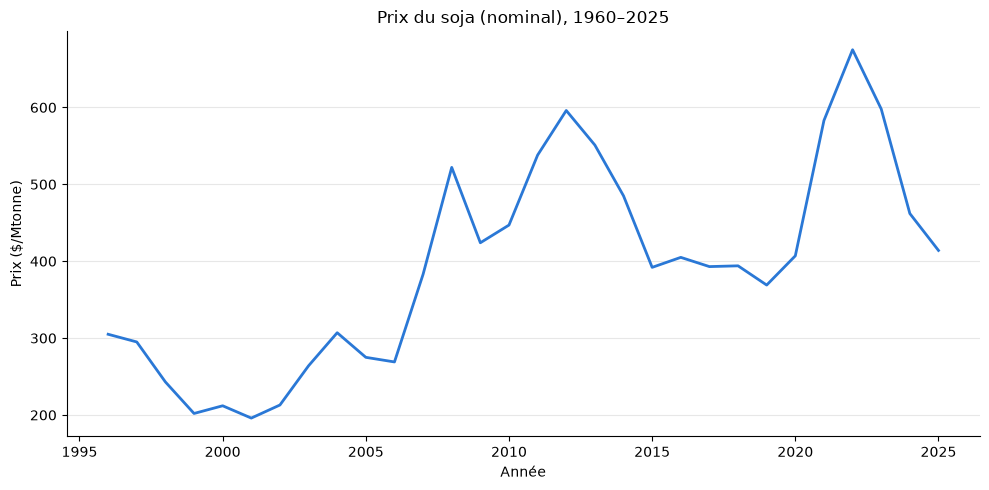

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybeans"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du soja (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


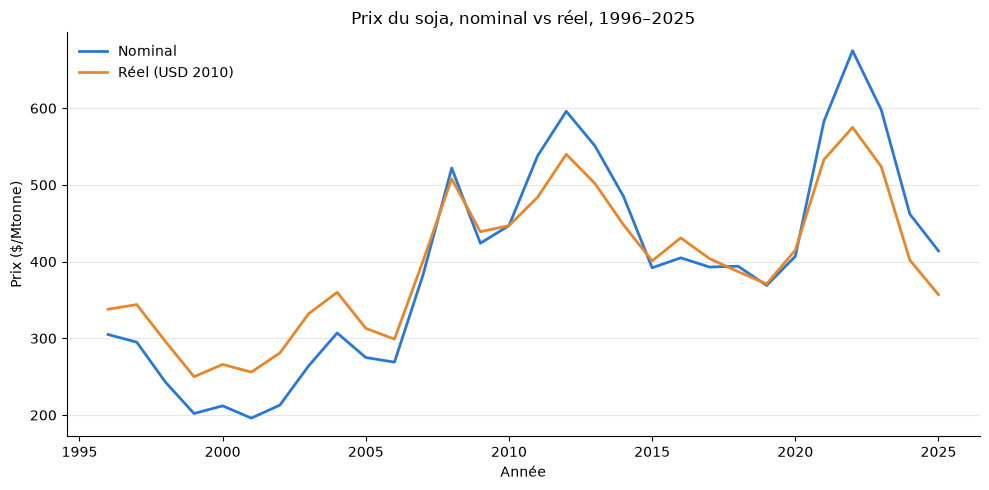

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybeans"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Soybeans"], color="#e8862a", linewidth=2, label="Réel (USD 2010)")
ax.set_title("Prix du soja, nominal vs réel, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


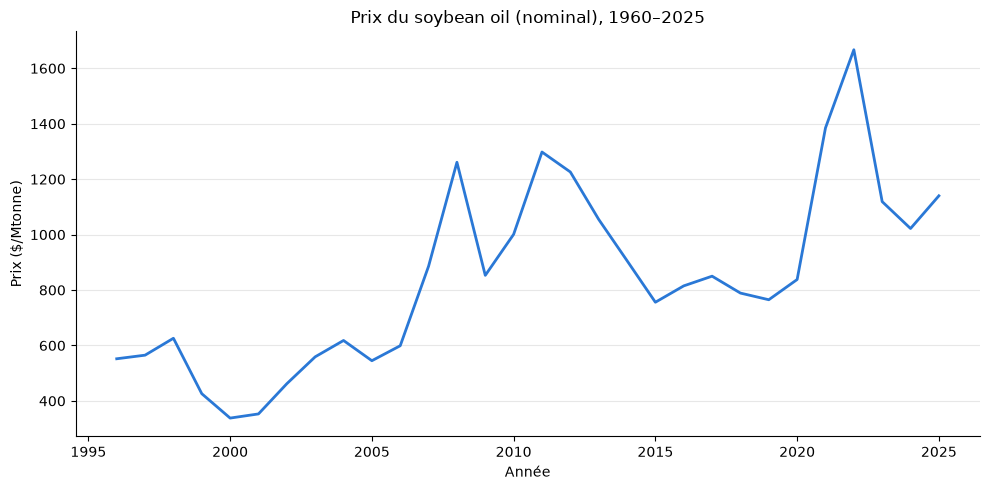

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybean oil"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du soybean oil (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

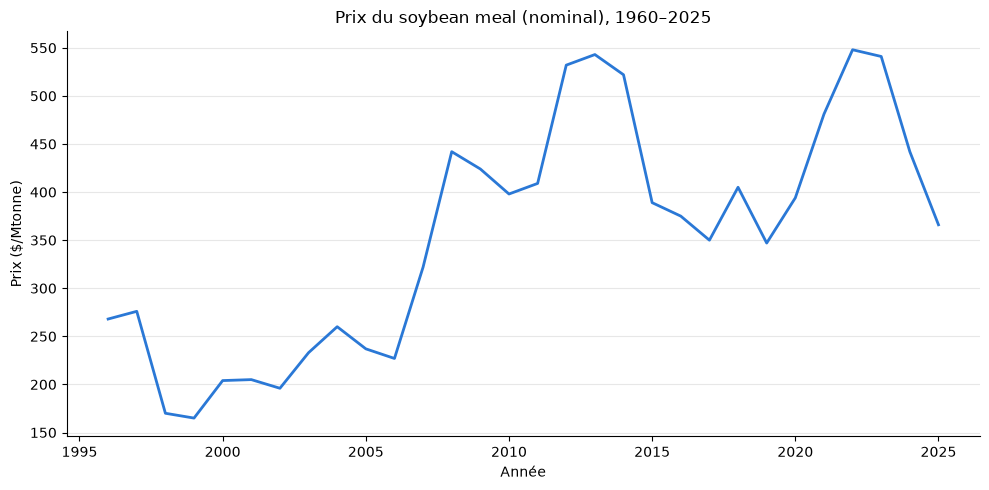

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybean meal"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du soybean meal (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

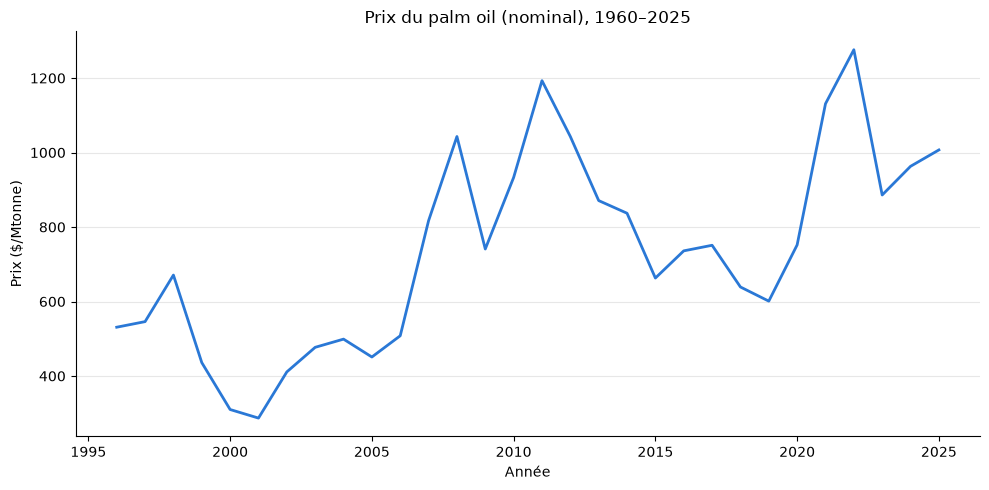

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm oil"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du palm oil (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

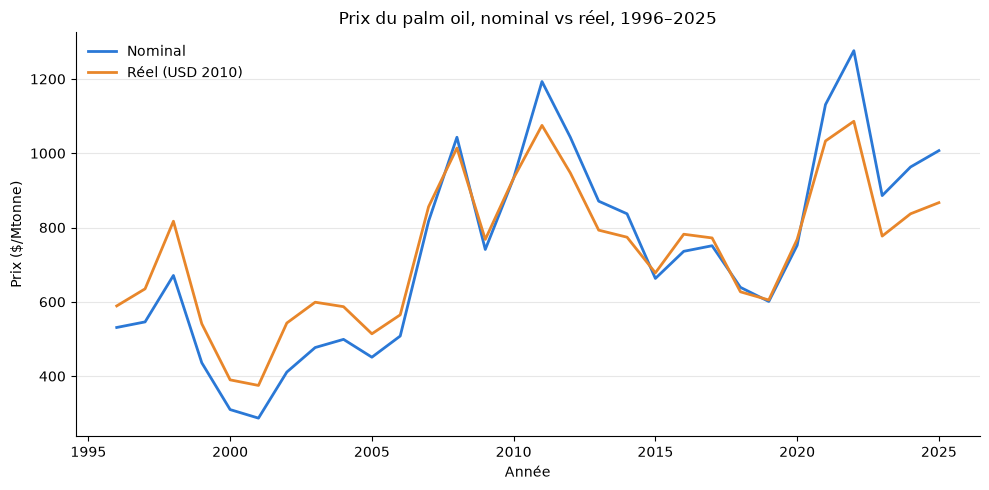

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm oil"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Palm oil"], color="#e8862a", linewidth=2, label="Réel (USD 2010)")
ax.set_title("Prix du palm oil, nominal vs réel, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

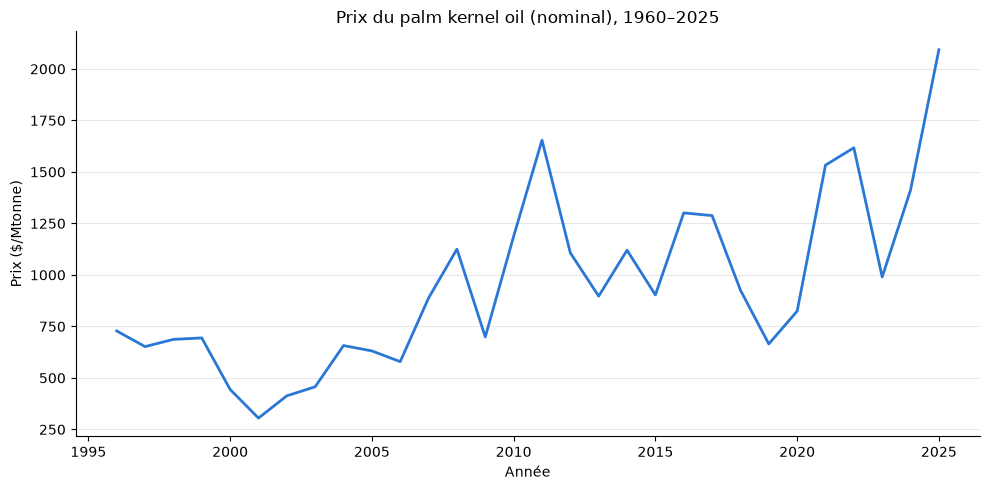

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm kernel oil"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du palm kernel oil (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

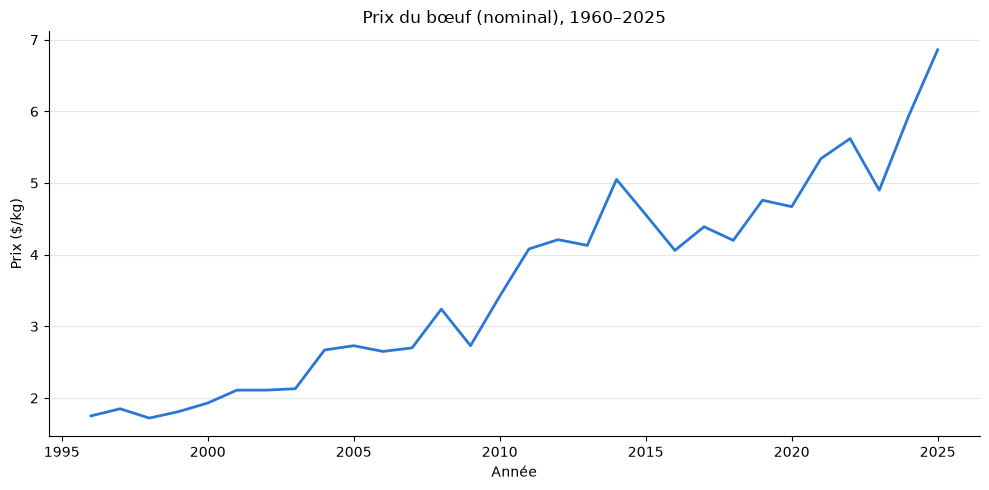

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Beef"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du bœuf (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/kg)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

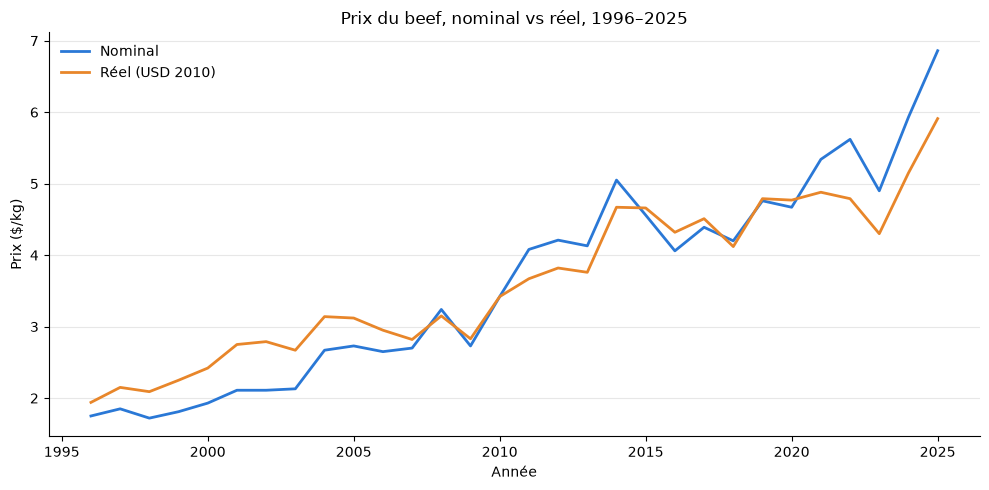

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Beef"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Beef"], color="#e8862a", linewidth=2, label="Réel (USD 2010)")
ax.set_title("Prix du beef, nominal vs réel, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/kg)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()





From here we start analysing price per country 


In [17]:
path = "../../data/raw/crops/FAOSTAT_data_en_10-7-2026.csv"
price_data = pd.read_csv(path)
price_data.head() 

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
0,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1993,1993,7021,Annual value,USD,3116.2,A,Official value
1,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1994,1994,7021,Annual value,USD,2071.4,A,Official value
2,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1995,1995,7021,Annual value,USD,2481.2,A,Official value
3,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1996,1996,7021,Annual value,USD,2870.8,A,Official value
4,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1997,1997,7021,Annual value,USD,2350.1,A,Official value


In [22]:
cattle = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Meat of cattle with the bone, fresh or chilled"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
cattle.head()



,Area,Item,Year,Unit,Value
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2


In [28]:
beef = df.loc[df["year"] >= 1996, ["year", "Beef"]]

cattle = cattle.merge(beef, left_on="Year", right_on="year", how="left").drop(columns="year")
cattle.head()


,Area,Item,Year,Unit,Value,Beef
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1.75
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1.85
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1.72
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1.81
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1.93


In [29]:

cattle["Beef"] = cattle["Beef"] * 1000
cattle = cattle.rename(columns={"Beef": "Prix mondial"})
cattle.head()


,Area,Item,Year,Unit,Value,Prix mondial
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1750.0
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1850.0
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1720.0
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1810.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1930.0


In [32]:
cattle["Difference"] = cattle["Value"] - cattle["Prix mondial"]
cattle.head()



,Area,Item,Year,Unit,Value,Prix mondial,Difference (%),Difference
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1750.0,64.045714,1120.8
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1850.0,27.032432,500.1
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1720.0,80.244186,1380.2
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1810.0,98.618785,1785.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1930.0,89.647668,1730.2


In [24]:
palm_oil = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Oil palm fruit"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
palm_oil.head()


,Area,Item,Year,Unit,Value
0,Brazil,Oil palm fruit,1996,USD,111.4
1,Brazil,Oil palm fruit,1997,USD,64.9
2,Brazil,Oil palm fruit,1998,USD,60.3
3,Brazil,Oil palm fruit,1999,USD,34.7
4,Brazil,Oil palm fruit,2000,USD,34.4


In [37]:

palm_oil = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Oil palm fruit"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)

palm = df.loc[df["year"] >= 1996, ["year", "Palm oil"]]
palm_oil = palm_oil.merge(palm, left_on="Year", right_on="year", how="left").drop(columns="year")
palm_oil = palm_oil.rename(columns={"Palm oil": "Prix mondial"})

palm_oil["Difference"] = palm_oil["Value"] - palm_oil["Prix mondial"]
palm_oil.head()




,Area,Item,Year,Unit,Value,Prix mondial,Difference
0,Brazil,Oil palm fruit,1996,USD,111.4,531,-419.6
1,Brazil,Oil palm fruit,1997,USD,64.9,546,-481.1
2,Brazil,Oil palm fruit,1998,USD,60.3,671,-610.7
3,Brazil,Oil palm fruit,1999,USD,34.7,436,-401.3
4,Brazil,Oil palm fruit,2000,USD,34.4,310,-275.6


In [26]:
soy = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Soya beans"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
soy.head()

,Area,Item,Year,Unit,Value
0,Albania,Soya beans,1996,USD,478.5
1,Albania,Soya beans,1997,USD,335.7
2,Albania,Soya beans,1998,USD,331.9
3,Albania,Soya beans,1999,USD,435.8
4,Albania,Soya beans,2000,USD,487.1
...,...,...,...,...,...
95,Azerbaijan,Soya beans,2004,USD,670.6
96,Azerbaijan,Soya beans,2005,USD,678.0
97,Azerbaijan,Soya beans,2006,USD,386.2
98,Azerbaijan,Soya beans,2007,USD,413.7


In [38]:

soy = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Soya beans"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)

soybeans = df.loc[df["year"] >= 1996, ["year", "Soybeans"]]
soy = soy.merge(soybeans, left_on="Year", right_on="year", how="left").drop(columns="year")
soy = soy.rename(columns={"Soybeans": "Prix mondial"})

soy["Difference"] = soy["Value"] - soy["Prix mondial"]

soy.head()


,Area,Item,Year,Unit,Value,Prix mondial,Difference
0,Albania,Soya beans,1996,USD,478.5,305,173.5
1,Albania,Soya beans,1997,USD,335.7,295,40.7
2,Albania,Soya beans,1998,USD,331.9,243,88.9
3,Albania,Soya beans,1999,USD,435.8,202,233.8
4,Albania,Soya beans,2000,USD,487.1,212,275.1
